In [1]:
#1) Data Cleaning
#a) Analyse missing Values in the data. If you found any, explore Imputation techniques which
#can be used to impute them. ?? 
#b) Check for outliers in the data, see if any of the columns in the data has to be modelled as
#numeric or categorical. If yes, explain the reasoning and do the conversion.
#d) Figure out irrelevant rows and columns. Based on your understanding, drop them
#e) Derive and explain insights based on descriptive statistics ??

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.preprocessing import OneHotEncoder

# Algorithm 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve,recall_score


In [3]:

df = pd.read_csv("C:\\Users\\vpaidmarri\\Desktop\\DS\\DataSets\\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
def html_log(message, color='green'):
    display(HTML(f"<b style='color:{color}'>{message}</b>"))

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
#a) Analyse missing Values in the data. If you found any, explore Imputation techniques which
#can be used to impute them. - 

In [7]:
df.isna().sum()
html_log('Observed no null values in the dataset')

In [8]:
#b) Check for outliers in the data, see if any of the columns in the data has to be modelled as
#numeric or categorical. If yes, explain the reasoning and do the conversion.

In [9]:
df.columns.unique()

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:
# Convert object to category

In [11]:
cat_cols = []

for cols in df.select_dtypes("object"):
    cat_cols.append(cols)
html_log(f'{cat_cols} : are converted to Category')
df[cat_cols] = df[cat_cols].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        10000 non-null  int64   
 1   CustomerId       10000 non-null  int64   
 2   Surname          10000 non-null  category
 3   CreditScore      10000 non-null  int64   
 4   Geography        10000 non-null  category
 5   Gender           10000 non-null  category
 6   Age              10000 non-null  int64   
 7   Tenure           10000 non-null  int64   
 8   Balance          10000 non-null  float64 
 9   NumOfProducts    10000 non-null  int64   
 10  HasCrCard        10000 non-null  int64   
 11  IsActiveMember   10000 non-null  int64   
 12  EstimatedSalary  10000 non-null  float64 
 13  Exited           10000 non-null  int64   
dtypes: category(3), float64(2), int64(9)
memory usage: 986.3 KB


In [12]:
# The number columns with unique values less than 5, convert them to categorical

In [13]:
for col in df.columns:  
    if df[col].dtype == 'int64' and df[col].nunique() < 5:
        html_log(f'Feature:{col} | unique values : {df[col].nunique()} changed to type: Category')
        df[col] = df[col].astype('category')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        10000 non-null  int64   
 1   CustomerId       10000 non-null  int64   
 2   Surname          10000 non-null  category
 3   CreditScore      10000 non-null  int64   
 4   Geography        10000 non-null  category
 5   Gender           10000 non-null  category
 6   Age              10000 non-null  int64   
 7   Tenure           10000 non-null  int64   
 8   Balance          10000 non-null  float64 
 9   NumOfProducts    10000 non-null  category
 10  HasCrCard        10000 non-null  category
 11  IsActiveMember   10000 non-null  category
 12  EstimatedSalary  10000 non-null  float64 
 13  Exited           10000 non-null  category
dtypes: category(7), float64(2), int64(5)
memory usage: 713.4 KB


In [15]:
# Box Plot
# draw a box plot to do the exploratory data analysis , with Exited Target variable

In [16]:
num_cols = []
for cols in df.select_dtypes(["int64",'float64']):
    num_cols.append(cols)

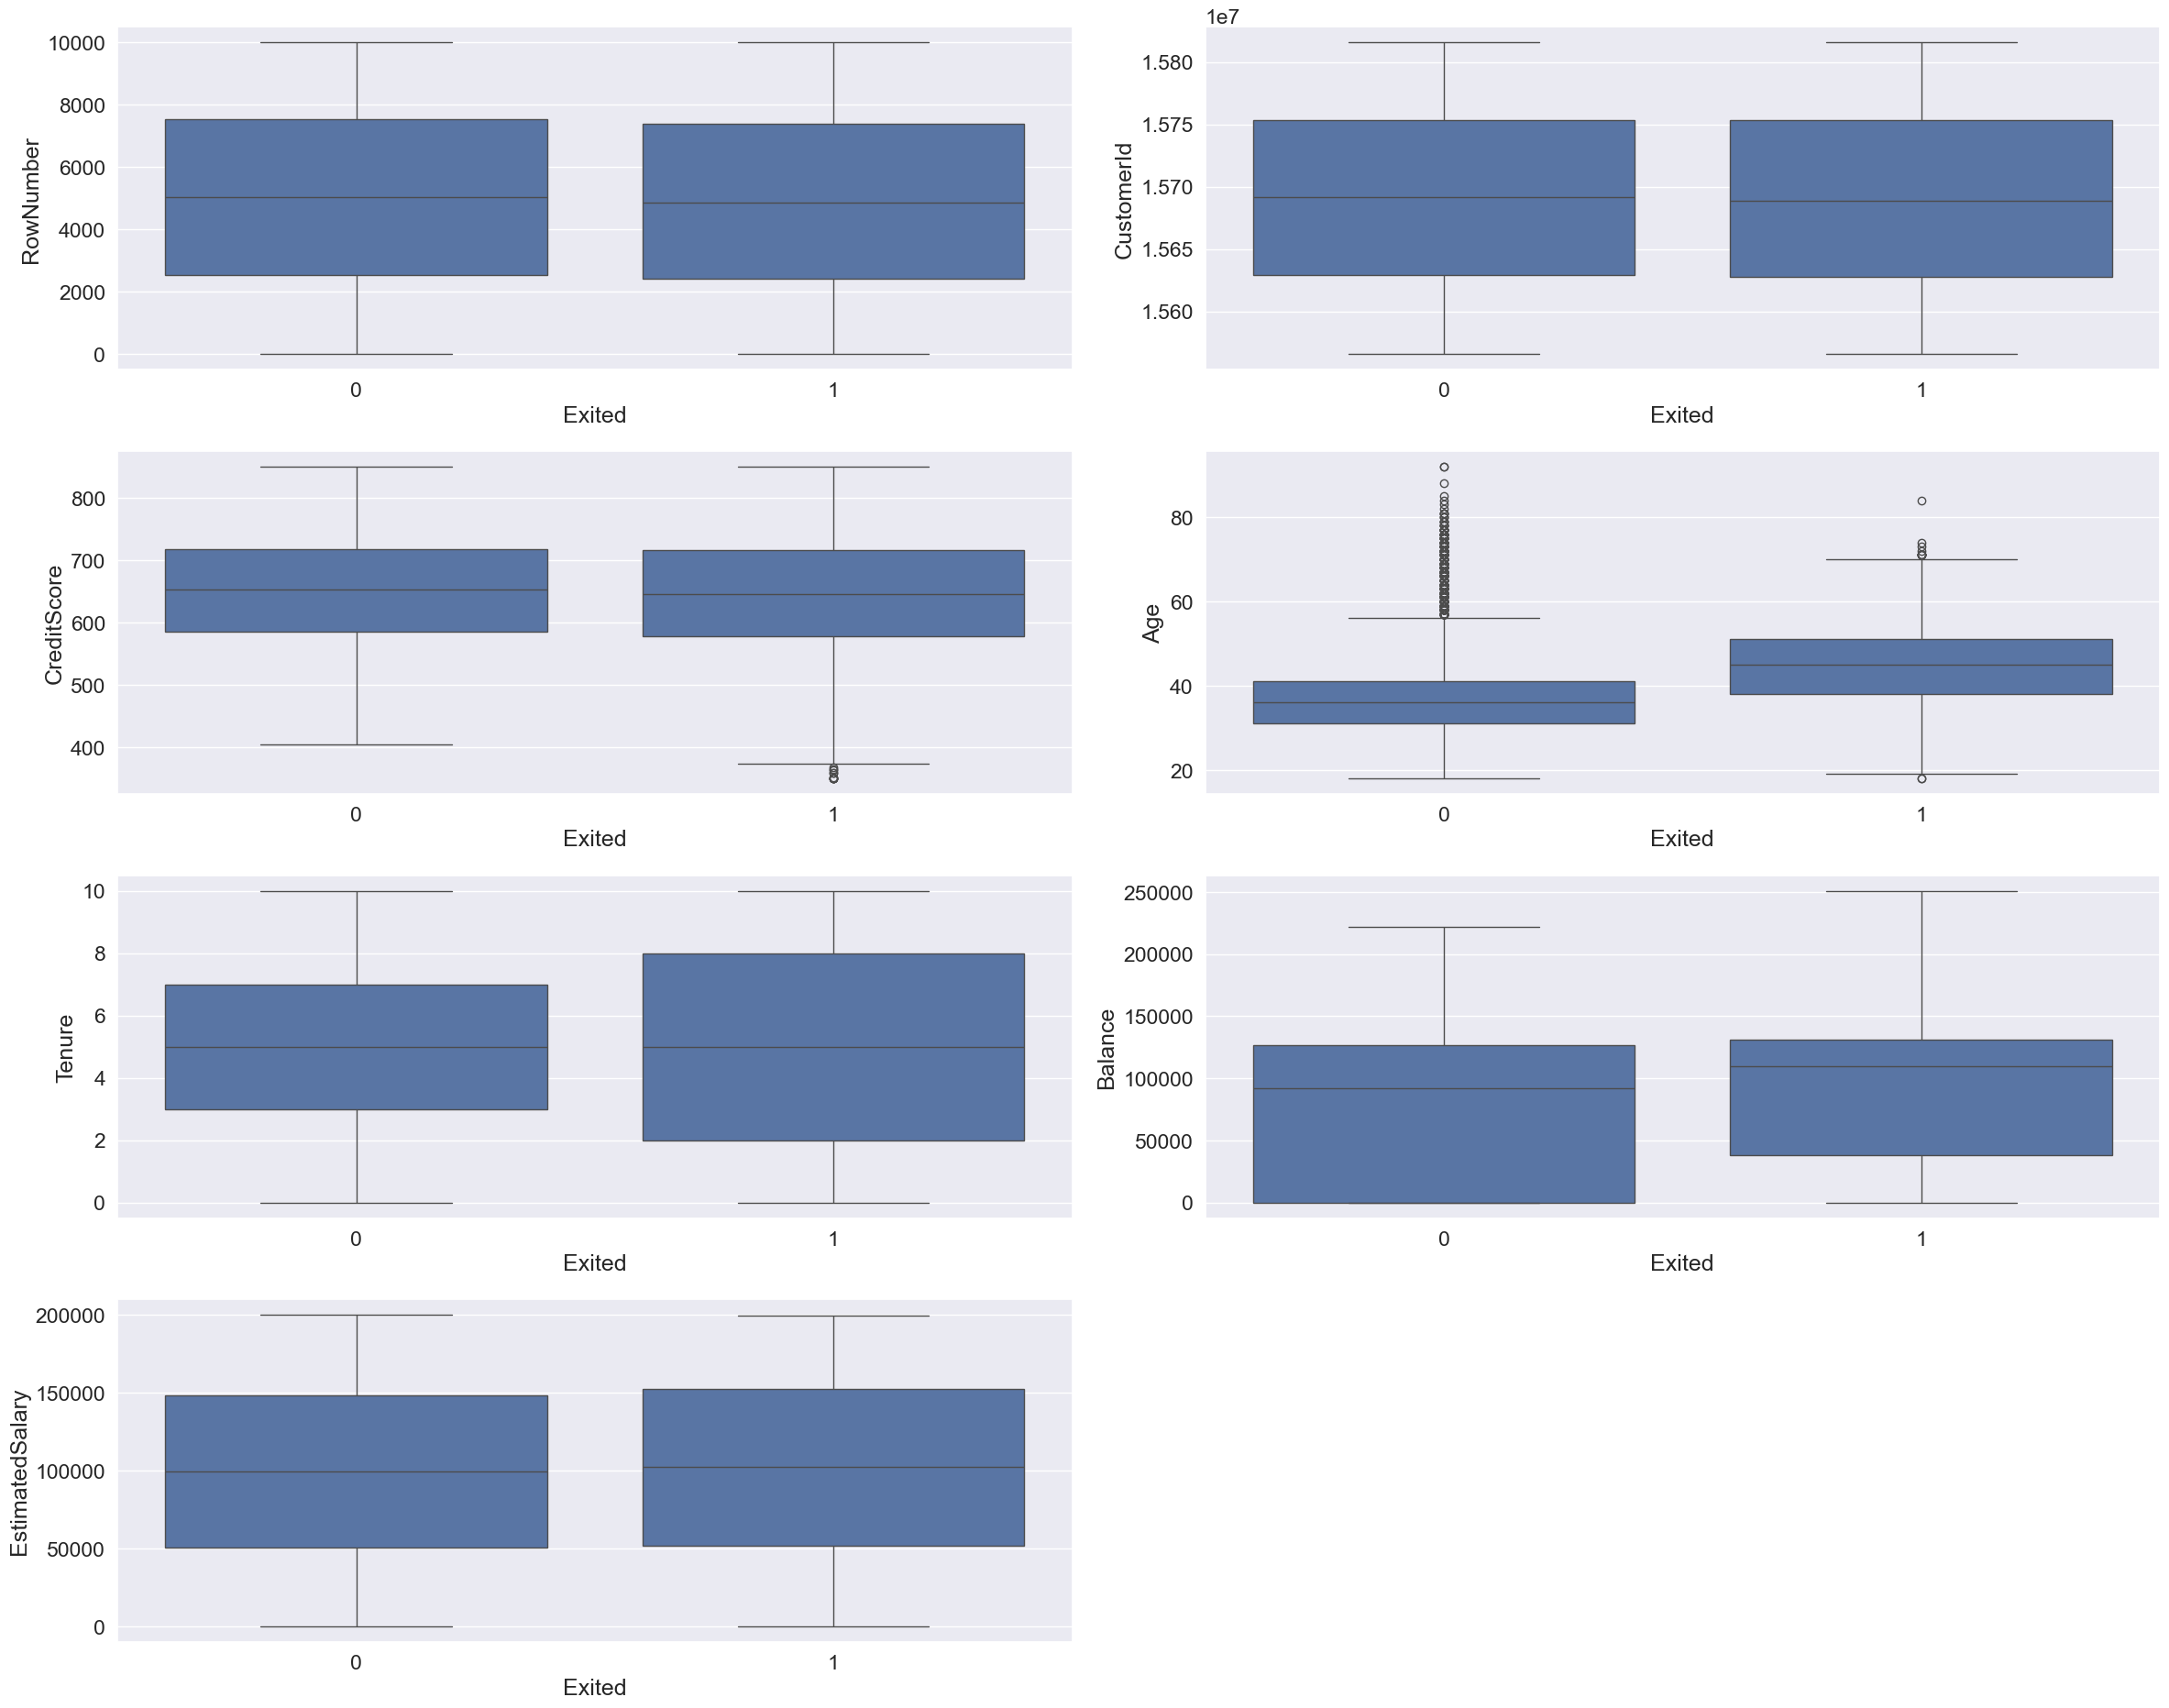

In [17]:
sns.set(font_scale=1.5)
fig = plt.figure(figsize=(24,60))
i=1
for column in df[num_cols]:
    plt.subplot(13,2,i)
    sns.boxplot(x=df['Exited'],y=df.loc[:,column])
    i = i + 1
    
plt.tight_layout()
plt.show()

In [18]:
#d) Figure out irrelevant rows and columns. Based on your understanding, drop them
#CustomerID and row number to be dropped as they not relevant

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        10000 non-null  int64   
 1   CustomerId       10000 non-null  int64   
 2   Surname          10000 non-null  category
 3   CreditScore      10000 non-null  int64   
 4   Geography        10000 non-null  category
 5   Gender           10000 non-null  category
 6   Age              10000 non-null  int64   
 7   Tenure           10000 non-null  int64   
 8   Balance          10000 non-null  float64 
 9   NumOfProducts    10000 non-null  category
 10  HasCrCard        10000 non-null  category
 11  IsActiveMember   10000 non-null  category
 12  EstimatedSalary  10000 non-null  float64 
 13  Exited           10000 non-null  category
dtypes: category(7), float64(2), int64(5)
memory usage: 713.4 KB


In [20]:
df = df[df.columns.drop(['CustomerId', 'RowNumber','Surname'])]

In [21]:
#?? - Irrelavant rows - handling outliers -applying IQR?
#TODO: #plot a IQR and check how much percentage is impacted
#TODO: Duplicates check

In [22]:
#e) Derive and explain insights based on descriptive statistics

In [23]:
df.describe()

,CreditScore,Age,Tenure,Balance,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,57510.492818
min,350.000000,18.000000,0.000000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,199992.480000


## 2) Exploratory Analysis

### a) Perform Univariate Analysis for all variables and comment on the insights
### ??? Univariate would be done for only Target variable or each independent variable???

In [24]:
def univariate_pie(df, col):
    counts = df[col].value_counts()

    print(f"\n--- {col} ---")
    print("Counts:\n", counts)
    #print("\nPercentage:\n", (counts / len(df)) * 100)

    plt.figure()
    plt.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f"{col} Distribution")
    plt.axis('equal')
    plt.show()




--- Geography ---
Counts:
 Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


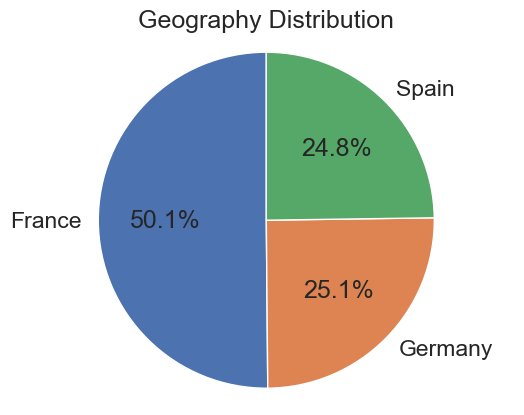


--- Gender ---
Counts:
 Gender
Male      5457
Female    4543
Name: count, dtype: int64


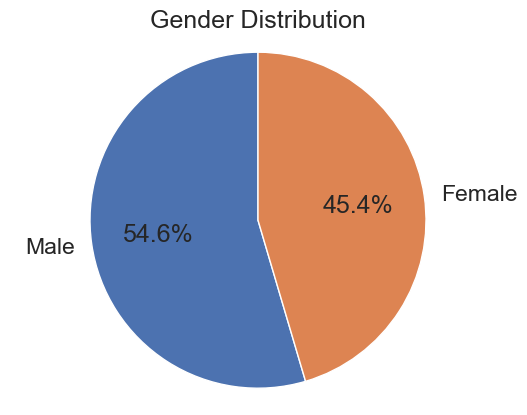


--- NumOfProducts ---
Counts:
 NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


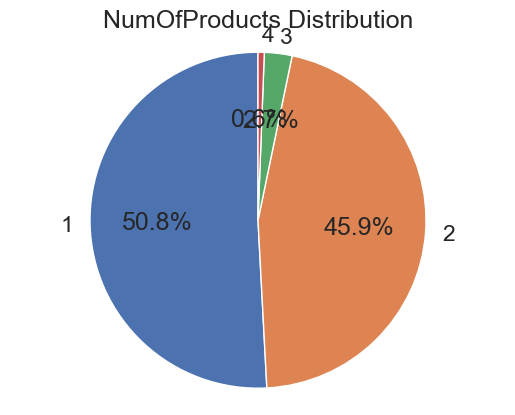


--- HasCrCard ---
Counts:
 HasCrCard
1    7055
0    2945
Name: count, dtype: int64


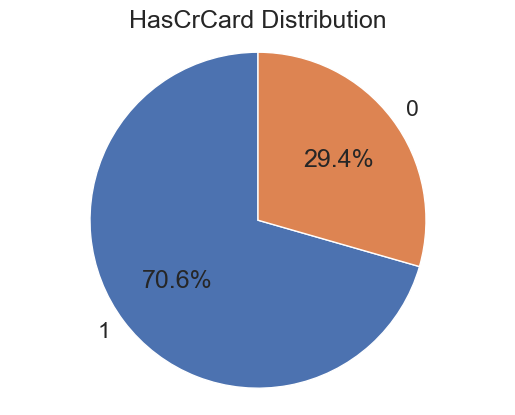


--- IsActiveMember ---
Counts:
 IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


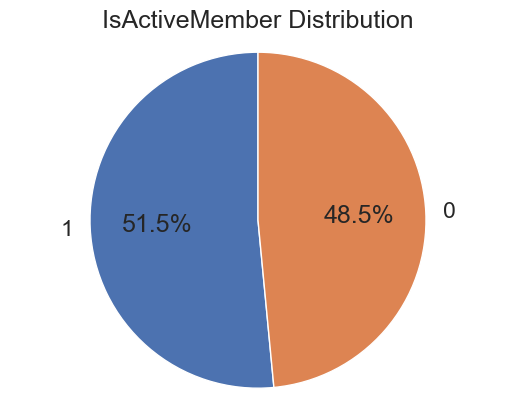


--- Exited ---
Counts:
 Exited
0    7963
1    2037
Name: count, dtype: int64


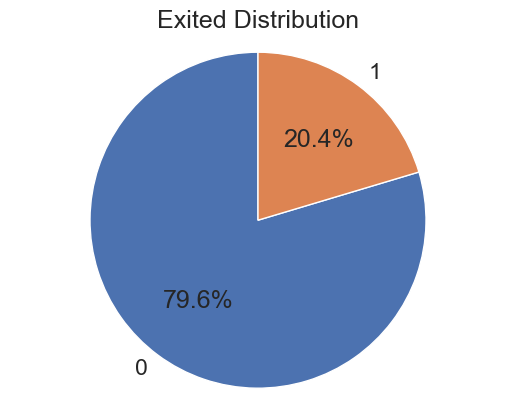

In [25]:
# Loop through all categorical columns
for col in df.select_dtypes(include=['category']).columns:
    univariate_pie(df, col)

In [26]:
def bivariate_analysis(data,col1,col2,rot):
    cross_tab = pd.crosstab(data[col1], data[col2]).apply(lambda x: x/x.sum() * 100, axis=1).round(2)
    print(cross_tab)
    ct_attr = cross_tab[1].sort_values(ascending=False)
    ct_attr.plot.bar(figsize=(8,5))
    plt.xlabel('{}'.format(col1))
    plt.ylabel('% of exited'.format(col1))
    plt.title('{} Vs Exited'.format(col1))
    plt.xticks(rotation=rot)
    plt.show()
    return ct_attr

Exited         0      1
Geography              
France     83.85  16.15
Germany    67.56  32.44
Spain      83.33  16.67


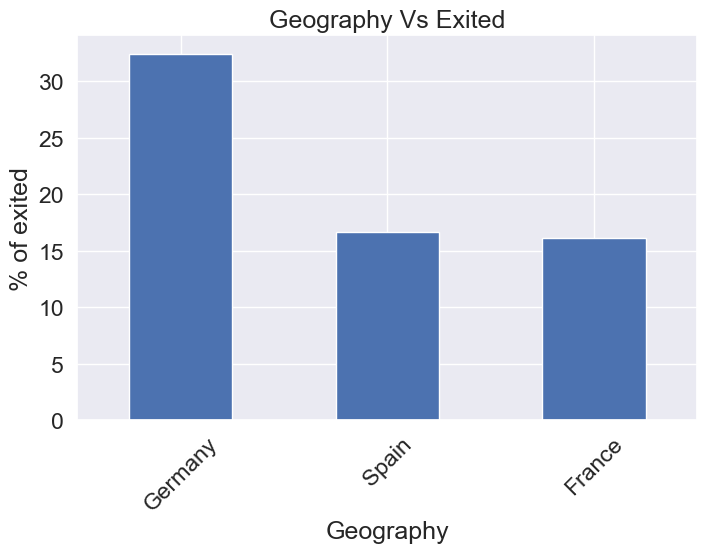

Exited      0      1
Gender              
Female  74.93  25.07
Male    83.54  16.46


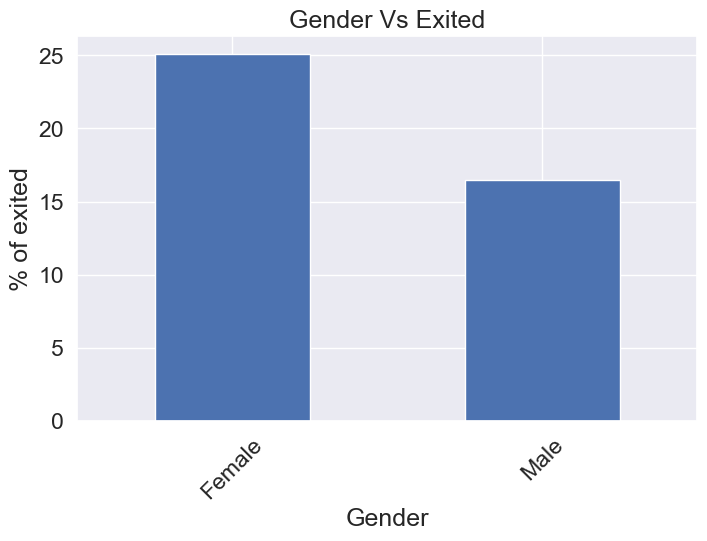

Exited             0       1
NumOfProducts               
1              72.29   27.71
2              92.42    7.58
3              17.29   82.71
4               0.00  100.00


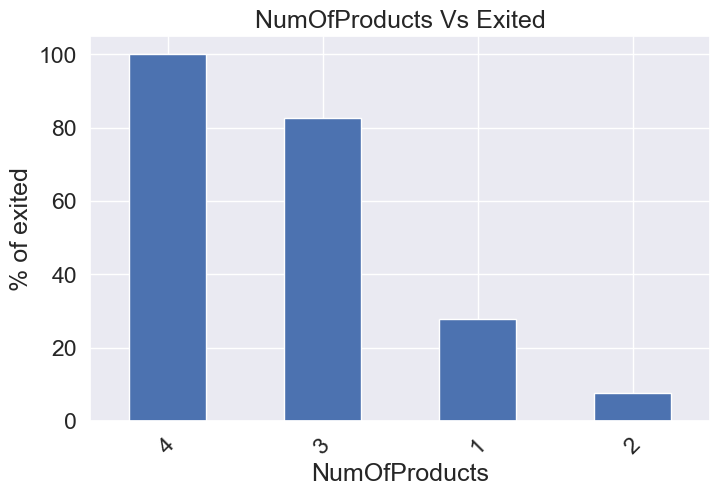

Exited         0      1
HasCrCard              
0          79.19  20.81
1          79.82  20.18


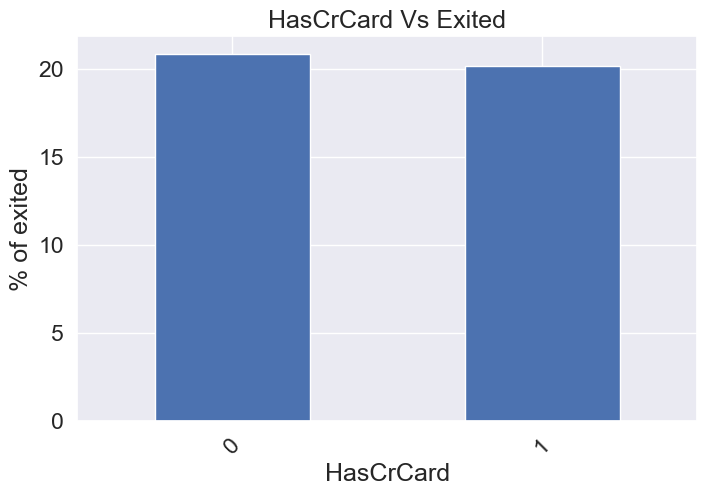

Exited              0      1
IsActiveMember              
0               73.15  26.85
1               85.73  14.27


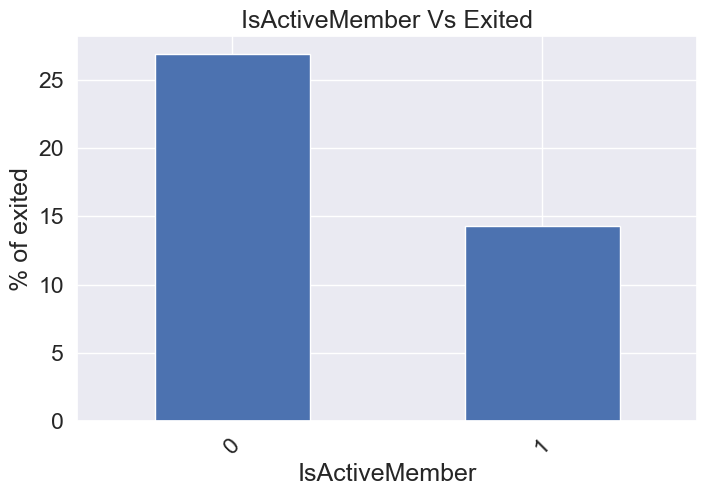

Exited      0      1
Exited              
0       100.0    0.0
1         0.0  100.0


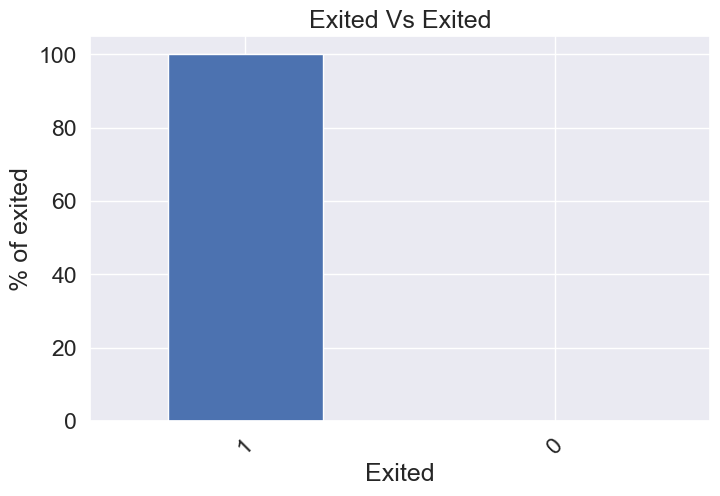

In [27]:
# Loop through all categorical columns
for col in df.select_dtypes(include=['category']).columns:
    bivariate_analysis(df, col,'Exited', 45)

##### Analysis: "HascrCard" has no impact to the chrun

### c) chi square test of dependency with all categorical and target 


In [28]:
# Linear Algebra
import numpy as np
from scipy.stats import chi2_contingency


In [29]:
cat_cols = df.select_dtypes(include=['category']).columns
chi2, p_values = [], []
for f in cat_cols: 
    chitest = chi2_contingency(pd.crosstab(df[f], df['Exited']))
    p_values.append(np.round(chitest[1],3))

chi_results = pd.DataFrame(p_values, index = cat_cols)
chi_results

,0
Geography,0.000
Gender,0.000
NumOfProducts,0.000
HasCrCard,0.492
IsActiveMember,0.000
Exited,0.000


##### Lowest the chi square value strongest you reject null hypothesis, 
##### p-value > 0.05 → NOT significant → weak/irrelevant | Feature HasCrCard values is > 0.05, so drop it

In [30]:
df = df[df.columns.drop(['HasCrCard'])]
html_log("Drop the feature : HasCrCard", "red")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  int64   
 1   Geography        10000 non-null  category
 2   Gender           10000 non-null  category
 3   Age              10000 non-null  int64   
 4   Tenure           10000 non-null  int64   
 5   Balance          10000 non-null  float64 
 6   NumOfProducts    10000 non-null  category
 7   IsActiveMember   10000 non-null  category
 8   EstimatedSalary  10000 non-null  float64 
 9   Exited           10000 non-null  category
dtypes: category(5), float64(2), int64(3)
memory usage: 440.3 KB


In [31]:
df['age_bins'] = pd.cut(df.Age,bins=[18,30,40,50,60],labels=['Young Customers',' Middle Age Customers','More Middle Age','Retirement Age'])

In [32]:
df['age_bins'] 

0             More Middle Age
1             More Middle Age
2             More Middle Age
3        Middle Age Customers
4             More Middle Age
                ...          
9995     Middle Age Customers
9996     Middle Age Customers
9997     Middle Age Customers
9998          More Middle Age
9999          Young Customers
Name: age_bins, Length: 10000, dtype: category
Categories (4, object): ['Young Customers' < ' Middle Age Customers' < 'More Middle Age' < 'Retirement Age']

Exited                     0      1
age_bins                           
Young Customers        92.50   7.50
 Middle Age Customers  87.91  12.09
More Middle Age        66.03  33.97
Retirement Age         43.79  56.21


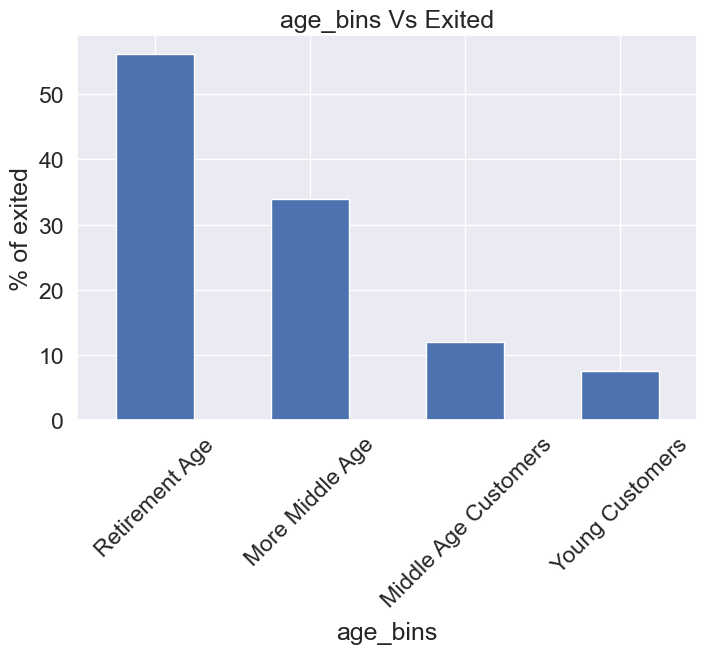

age_bins
Retirement Age           56.21
More Middle Age          33.97
 Middle Age Customers    12.09
Young Customers           7.50
Name: 1, dtype: float64

In [33]:
bivariate_analysis(df,'age_bins','Exited',45)

##### AGE: Chrun is more as the age increases, chi-sqaure test supports the fact as well,  p values is very less, Null hypothesis is rejected

In [34]:
age_chi_results = chi2_contingency(pd.crosstab(df['age_bins'], df['Exited'],margins=True))
html_log(f"Tenure Chi-Square is : {np.round(age_chi_results[1],4)}", "green")

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  int64   
 1   Geography        10000 non-null  category
 2   Gender           10000 non-null  category
 3   Age              10000 non-null  int64   
 4   Tenure           10000 non-null  int64   
 5   Balance          10000 non-null  float64 
 6   NumOfProducts    10000 non-null  category
 7   IsActiveMember   10000 non-null  category
 8   EstimatedSalary  10000 non-null  float64 
 9   Exited           10000 non-null  category
 10  age_bins         9514 non-null   category
dtypes: category(6), float64(2), int64(3)
memory usage: 450.2 KB


##### Tenure: Chrun does not impacted with tenure, chi-sqaure test supports the fact as well,  p value > 0.05, Null hypothesis hold good
#### DROP Tenure and repective Bin

In [36]:
print(df["Tenure"].unique())

[ 2  1  8  7  4  6  3 10  5  9  0]


In [37]:
df['Tenure_bins'] = pd.cut(df.Tenure,bins=[2,4,6,8],labels=['First',' Second','Third'])

Exited           0      1
Tenure_bins              
First        79.18  20.82
 Second      79.54  20.46
Third        81.78  18.22


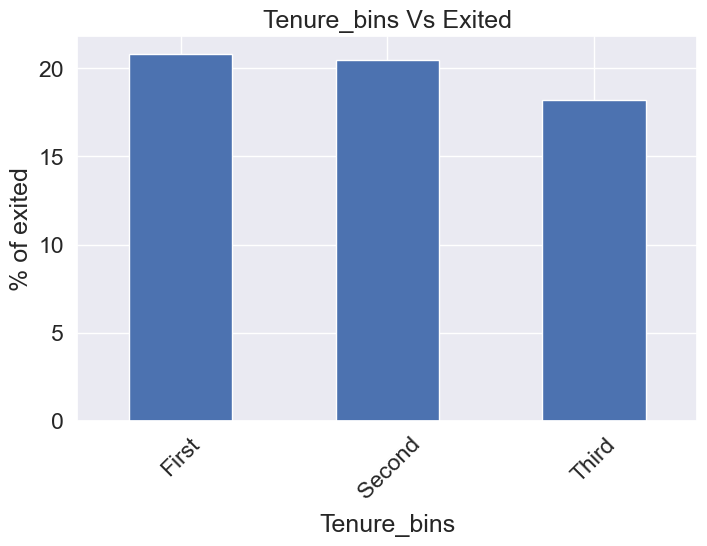

Tenure_bins
First      20.82
 Second    20.46
Third      18.22
Name: 1, dtype: float64

In [38]:
bivariate_analysis(df,'Tenure_bins','Exited',45)

In [39]:
tenure_chi_results = chi2_contingency(pd.crosstab(df['Tenure_bins'], df['Exited'],margins=True))
html_log(f"Tenure Chi-Square is : {np.round(tenure_chi_results[1],4)}", "red")

##### Tenure: Convert to Categorical and verify the bivariate and CHi Square

In [40]:
df["Tenure"] = df["Tenure"].astype("category")

Exited      0      1
Tenure              
0       77.00  23.00
1       77.58  22.42
2       80.82  19.18
3       78.89  21.11
4       79.47  20.53
5       79.35  20.65
6       79.73  20.27
7       82.78  17.22
8       80.78  19.22
9       78.35  21.65
10      79.39  20.61


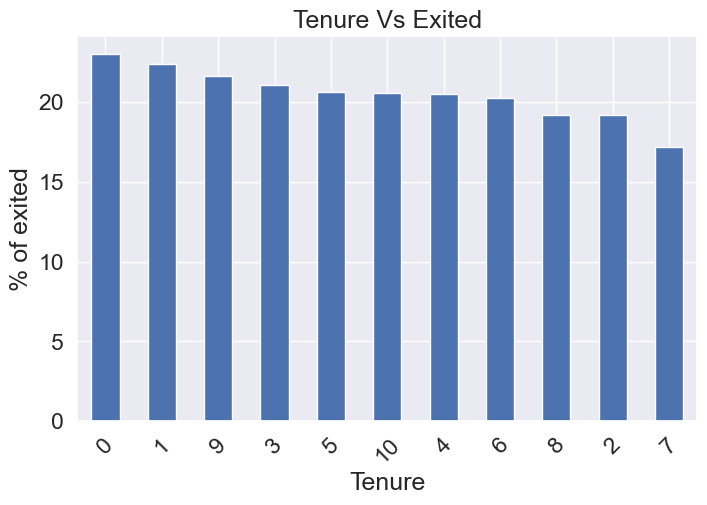

Tenure
0     23.00
1     22.42
9     21.65
3     21.11
5     20.65
10    20.61
4     20.53
6     20.27
8     19.22
2     19.18
7     17.22
Name: 1, dtype: float64

In [41]:
bivariate_analysis(df,'Tenure','Exited',45)

In [42]:
tenure_chi_results = chi2_contingency(pd.crosstab(df['Tenure'], df['Exited'],margins=True))
html_log(f"Tenure Chi-Square is : {np.round(tenure_chi_results[1],4)}", "red")

In [43]:
df = df[df.columns.drop(['Tenure','Tenure_bins','age_bins'])]
html_log("Drop the feature : ['Tenure','Tenure_bin','age_bins']", "red")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      10000 non-null  int64   
 1   Geography        10000 non-null  category
 2   Gender           10000 non-null  category
 3   Age              10000 non-null  int64   
 4   Balance          10000 non-null  float64 
 5   NumOfProducts    10000 non-null  category
 6   IsActiveMember   10000 non-null  category
 7   EstimatedSalary  10000 non-null  float64 
 8   Exited           10000 non-null  category
dtypes: category(5), float64(2), int64(2)
memory usage: 362.1 KB


## Data Preparation for model - one hot encoding

In [44]:
df_encoded = pd.get_dummies(df, columns=['Geography','Gender','NumOfProducts'], drop_first=True)
df_encoded

,CreditScore,Age,Balance,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4
0,619,42,0.00,1,101348.88,1,False,False,False,False,False,False
1,608,41,83807.86,1,112542.58,0,False,True,False,False,False,False
2,502,42,159660.80,0,113931.57,1,False,False,False,False,True,False
3,699,39,0.00,0,93826.63,0,False,False,False,True,False,False
4,850,43,125510.82,1,79084.10,0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,0.00,0,96270.64,0,False,False,True,True,False,False
9996,516,35,57369.61,1,101699.77,0,False,False,True,False,False,False
9997,709,36,0.00,1,42085.58,1,False,False,False,False,False,False
9998,772,42,75075.31,0,92888.52,1,True,False,True,True,False,False


In [45]:
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [46]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   CreditScore        10000 non-null  int64   
 1   Age                10000 non-null  int64   
 2   Balance            10000 non-null  float64 
 3   IsActiveMember     10000 non-null  category
 4   EstimatedSalary    10000 non-null  float64 
 5   Exited             10000 non-null  category
 6   Geography_Germany  10000 non-null  int64   
 7   Geography_Spain    10000 non-null  int64   
 8   Gender_Male        10000 non-null  int64   
 9   NumOfProducts_2    10000 non-null  int64   
 10  NumOfProducts_3    10000 non-null  int64   
 11  NumOfProducts_4    10000 non-null  int64   
dtypes: category(2), float64(2), int64(8)
memory usage: 801.2 KB


#### Train Test and split

In [47]:
X = df_encoded.drop(columns = 'Exited').copy()
Y = pd.DataFrame(df_encoded['Exited'])

X_train,X_test,Y_train,Y_test = train_test_split(X ,Y ,test_size=0.3, stratify=Y,random_state=0)

In [48]:
print(X_train.head())
print(X_train.nunique())

      CreditScore  Age    Balance IsActiveMember  EstimatedSalary  \
4380          438   59  127197.14              0         51565.98   
937           850   44  128605.32              1        171096.20   
7803          619   52  124099.13              0         23904.52   
6913          564   36  206329.65              1         46632.87   
8261          670   38       0.00              1         77864.41   

      Geography_Germany  Geography_Spain  Gender_Male  NumOfProducts_2  \
4380                  1                0            1                0   
937                   1                0            0                0   
7803                  1                0            0                0   
6913                  0                0            0                0   
8261                  0                0            1                1   

      NumOfProducts_3  NumOfProducts_4  
4380                0                0  
937                 0                0  
7803             

#### Train Test and split

In [49]:
X_train.describe()

,CreditScore,Age,Balance,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,649.649143,38.926000,76364.820889,99961.451814,0.248857,0.247857,0.542286,0.452714,0.028000,0.005429
std,96.514551,10.454138,62260.838781,57524.394093,0.432382,0.431799,0.498244,0.497795,0.164985,0.073484
min,350.000000,18.000000,0.000000,90.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,32.000000,0.000000,51014.837500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,651.000000,37.000000,96908.790000,99823.380000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,717.000000,44.000000,127823.275000,148980.577500,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,850.000000,92.000000,250898.090000,199992.480000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Normalize the data
#### ???? Nomralize the data set? instead of train's . 2) Can we apply standad scalar or robut scalar here?
#### TODO: Expirement Standard scalar

In [50]:
from sklearn.preprocessing import MinMaxScaler
cols_norm = ['CreditScore','Balance','EstimatedSalary']
minmax = MinMaxScaler()
X_train[cols_norm] = minmax.fit_transform(X_train[cols_norm].values)
X_test[cols_norm] = minmax.transform(X_test[cols_norm].values)

# Modeling

In [51]:
#a) Build a model based on logistic regression using stats models.

### Logistic Regression using Statsmodel
##### | Coef        | Meaning           |
##### | +ve         | increases churn   |
##### | -ve         | decreases churn   |
##### | large value | strong effect     |
##### | p < 0.05    | trustworthy       |
##### | exp(coef)   | real-world impact |


In [52]:
import statsmodels.api as sm
X_train = sm.add_constant(X_train)
model = sm.Logit(Y_train,X_train.astype(float))
result = model.fit(method='bfgs', maxiter = 1000)
result.summary()

Optimization terminated successfully.
         Current function value: 0.368391
         Iterations: 105
         Function evaluations: 108
         Gradient evaluations: 108


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6988
Method:                           MLE   Df Model:                           11
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.2712
Time:                        15:03:03   Log-Likelihood:                -2578.7
converged:                       True   LL-Null:                       -3538.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -3.2333      0.203    -15.926      0.000      -3.631      -2.835
CreditScore          -0.4029      0.183     -2.203      0.028      -0.761      -0.045
Age                   0.0737      0.003     22.150      0.000       0.067       0.080
Balance              -0.1707      0.172     -0.992      0.321      -0.508       0.167
IsActiveMember       -1.1053      0.075    -14.822      0.000      -1.251      -0.959
EstimatedSalary       0.1710      0.123      1.386      0.166      -0.071       0.413
Geography_Germany     0.8681      0.088      9.887      0.000       0.696       1.040
Geography_Spain       0.0054      0.091      0.060      0.952      -0.173       0.184
Gender_Male          -0.5694      0.071     -8.021      0.000      -0.709      -0.430
NumOfProducts_2      -1.5974      0.087    -18.414      0.000      -1.767      -1.427
NumOfProducts_3       2.6754      0.214     12.484      0.000       2.255       3.095
NumOfProducts_4      14.9312    198.265      0.075      0.940    -373.662     403.524
=====================================================================================
"""

#### drop  the column:NumOfProducts_4 and build the model

In [53]:
html_log("#### ??? Should we exclude all varibales with P < 0.005?", "purple")

In [54]:
X_train.drop(['NumOfProducts_4'], axis =1 , inplace = True)
X_test.drop(['NumOfProducts_4'], axis =1 , inplace = True)

In [55]:
X_train.head()

,const,CreditScore,Age,Balance,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,NumOfProducts_2,NumOfProducts_3
4380,1.0,0.176,59,0.506967,0,0.257505,1,0,1,0,0
937,1.0,1.000,44,0.512580,1,0.855448,1,0,0,0,0
7803,1.0,0.538,52,0.494620,0,0.119130,1,0,0,0,0
6913,1.0,0.428,36,0.822364,1,0.232828,0,0,0,0,0
8261,1.0,0.640,38,0.000000,1,0.389062,0,0,1,1,0


#### Re-run the stats model

In [56]:
model = sm.Logit(Y_train,X_train.astype(float))
result = model.fit(method='bfgs', maxiter = 100)
result.summary()

Optimization terminated successfully.
         Current function value: 0.373625
         Iterations: 79
         Function evaluations: 82
         Gradient evaluations: 82


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6989
Method:                           MLE   Df Model:                           10
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.2609
Time:                        15:03:03   Log-Likelihood:                -2615.4
converged:                       True   LL-Null:                       -3538.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -3.1953      0.201    -15.874      0.000      -3.590      -2.801
CreditScore          -0.4285      0.181     -2.365      0.018      -0.784      -0.073
Age                   0.0742      0.003     22.447      0.000       0.068       0.081
Balance              -0.1951      0.171     -1.143      0.253      -0.530       0.139
IsActiveMember       -1.0830      0.074    -14.691      0.000      -1.228      -0.939
EstimatedSalary       0.1647      0.122      1.346      0.178      -0.075       0.405
Geography_Germany     0.8786      0.087     10.096      0.000       0.708       1.049
Geography_Spain      -0.0116      0.090     -0.128      0.898      -0.189       0.166
Gender_Male          -0.5807      0.070     -8.248      0.000      -0.719      -0.443
NumOfProducts_2      -1.6402      0.087    -18.957      0.000      -1.810      -1.471
NumOfProducts_3       2.6361      0.214     12.305      0.000       2.216       3.056
=====================================================================================
"""

#### Logistic Regression Model

In [57]:
X_train.drop('const', axis =1 , inplace = True)

In [58]:
Y_train.head()

,Exited
4380,1
937,0
7803,0
6913,1
8261,0


In [59]:
# intialise the model
#logReg = LogisticRegression()
logReg = LogisticRegression(solver='saga', max_iter=1000)
Y_train = Y_train["Exited"]
# Training the model and storing information learned from the data
logReg.fit(X_train, Y_train)


# Predict labels for test data
y_train_pred = logReg.predict(X_train)
y_test_pred = logReg.predict(X_test) 

# Predict probabilities
y_train_pred_prob = logReg.predict_proba(X_train)
y_test_pred_prob = logReg.predict_proba(X_test)

In [60]:
# Score method to get accuracy of model
score = logReg.score(X_train,Y_train)
print("Accuracy score on train data:",score)

score = logReg.score(X_test,Y_test)
print("Accuracy score on test data:",score)

Accuracy score on train data: 0.8407142857142857
Accuracy score on test data: 0.8273333333333334
